# Concept Drift Detection via Year-Pair Discrimination

This notebook detects drift by training a classifier to distinguish adjacent years:
- label `0` for year `t-1`
- label `1` for year `t`

A high ROC-AUC indicates stronger separability between adjacent years (potential concept/data drift signal).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

from scipy.spatial.distance import cdist, pdist
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
data_path = "training_data_with_features.zarr"
split_path = "data_split.npz"

ds = xr.open_zarr(data_path)
splits = np.load(split_path)

train_pixel_indices = splits["train_pixel_indices"]
val_pixel_indices = splits["val_pixel_indices"]
test_pixel_indices = splits["test_pixel_indices"]

years = ds.year.values
print(f"Dataset loaded. Year range: {years.min()} - {years.max()} ({len(years)} years)")
print(f"Pixels: train={len(train_pixel_indices):,}, val={len(val_pixel_indices):,}, test={len(test_pixel_indices):,}")

Dataset loaded. Year range: 2016 - 2022 (7 years)
Pixels: train=5,597,776, val=1,273,437, test=1,283,992


In [3]:
# Diagnostics
test_subset = ds.isel(pixel=train_pixel_indices[:100])
print(f"Test subset s2_bands shape: {test_subset.s2_bands.shape}")
print(f"Test subset s2_bands dims: {test_subset.s2_bands.dims}")
print(f"All dims: {test_subset.dims}")

Test subset s2_bands shape: (100, 7, 7)
Test subset s2_bands dims: ('pixel', 'year', 's2_band')
All dims: FrozenMappingWarningOnValuesAccess({'pixel': 100, 'year': 7, 's2_band': 7})


In [4]:
def prepare_features_for_year(ds_subset, year_idx):
    """Prepare per-pixel features for a given year index (simplified: no deltas, no DEM)."""
    if year_idx == 0:
        return None, None

    valid_mask = ds_subset.disturbances[:, year_idx].values != 255

    s2_data = ds_subset.s2_bands.values  # shape (n_pixels, n_years, n_bands)
    s2_t = s2_data[:, year_idx, :].copy()  # shape (n_pixels, n_bands)
    
    # Vectorized NaN imputation: per-pixel, per-band mean across years
    nan_mask = np.isnan(s2_t)
    if np.any(nan_mask):
        band_means = np.nanmean(s2_data, axis=1)  # shape (n_pixels, n_bands)
        s2_t[nan_mask] = band_means[nan_mask]

    # Feature set: S2 bands only
    feature_list = [
        s2_t,  # shape (n_pixels, n_bands)
    ]

    X = np.concatenate(feature_list, axis=1)
    y = ds_subset.disturbances[:, year_idx].values

    # Combined mask: valid disturbance + binary label + finite features
    keep_mask = valid_mask & np.isin(y, [0, 1]) & np.all(np.isfinite(X), axis=1)
    X = X[keep_mask]
    y = y[keep_mask]

    if len(X) == 0:
        return None, None

    return X, y


def build_pair_dataset_cached(X_prev, y_prev, X_curr, y_curr):
    """Build binary year-pair dataset from pre-computed features (fast)."""
    if X_prev is None or X_curr is None:
        return None, None

    if X_prev.shape[1] != X_curr.shape[1]:
        return None, None

    X_pair = np.vstack([X_prev, X_curr])
    y_pair = np.concatenate([
        np.zeros(len(y_prev), dtype=np.uint8),
        np.ones(len(y_curr), dtype=np.uint8),
    ])

    return X_pair, y_pair

In [5]:
# Configuration
SAMPLE_FRACTION = 1.0  # Use 1.0 for full dataset, 0.1 for 10% sample (faster iteration)

year_values = ds.year.values
n_years = len(year_values)
n_pairs = n_years - 2

# Sample pixel indices if configured
if SAMPLE_FRACTION < 1.0:
    print(f"Sampling {SAMPLE_FRACTION*100:.0f}% of pixels for faster iteration...")
    train_sample = np.random.choice(train_pixel_indices,
                                    size=int(len(train_pixel_indices) * SAMPLE_FRACTION),
                                    replace=False)
    val_sample = np.random.choice(val_pixel_indices,
                                  size=int(len(val_pixel_indices) * SAMPLE_FRACTION),
                                  replace=False)
    test_sample = np.random.choice(test_pixel_indices,
                                   size=int(len(test_pixel_indices) * SAMPLE_FRACTION),
                                   replace=False)
    print(f"Sampled: train={len(train_sample):,}, val={len(val_sample):,}, test={len(test_sample):,}\n")
else:
    train_sample = train_pixel_indices
    val_sample = val_pixel_indices
    test_sample = test_pixel_indices

# Pre-subset datasets once (lazy - no immediate memory load)
ds_train = ds.isel(pixel=train_sample)
ds_val = ds.isel(pixel=val_sample)
ds_test = ds.isel(pixel=test_sample)

print(f"Starting training on {n_pairs} adjacent year pairs...\n")
print(f"{'='*70}")

results = []
skipped_pairs = []
start_time = time.time()

for pair_idx, idx_curr in enumerate(range(2, n_years), start=1):
    idx_prev = idx_curr - 1
    year_prev = int(year_values[idx_prev])
    year_curr = int(year_values[idx_curr])
    pair_name = f"{year_prev} vs {year_curr}"

    pair_start = time.time()
    print(f"\n[{pair_idx}/{n_pairs}] {pair_name}")
    print("-" * 70)

    # Build features for this pair only (on-demand, not cached)
    print(f"  → Preparing train features ({year_prev} + {year_curr})...", end=" ", flush=True)
    feat_start = time.time()
    X_train_prev, y_train_prev = prepare_features_for_year(ds_train, idx_prev)
    X_train_curr, y_train_curr = prepare_features_for_year(ds_train, idx_curr)
    X_train, y_train = build_pair_dataset_cached(X_train_prev, y_train_prev, X_train_curr, y_train_curr)
    feat_time = time.time() - feat_start
    if y_train is not None:
        print(f"{len(y_train):,} samples in {feat_time:.1f}s")
    else:
        print("FAILED")

    print(f"  → Preparing val features ({year_prev} + {year_curr})...", end=" ", flush=True)
    feat_start = time.time()
    X_val_prev, y_val_prev = prepare_features_for_year(ds_val, idx_prev)
    X_val_curr, y_val_curr = prepare_features_for_year(ds_val, idx_curr)
    X_val, y_val = build_pair_dataset_cached(X_val_prev, y_val_prev, X_val_curr, y_val_curr)
    feat_time = time.time() - feat_start
    if y_val is not None:
        print(f"{len(y_val):,} samples in {feat_time:.1f}s")
    else:
        print("FAILED")

    print(f"  → Preparing test features ({year_prev} + {year_curr})...", end=" ", flush=True)
    feat_start = time.time()
    X_test_prev, y_test_prev = prepare_features_for_year(ds_test, idx_prev)
    X_test_curr, y_test_curr = prepare_features_for_year(ds_test, idx_curr)
    X_test, y_test = build_pair_dataset_cached(X_test_prev, y_test_prev, X_test_curr, y_test_curr)
    feat_time = time.time() - feat_start
    if y_test is not None:
        print(f"{len(y_test):,} samples in {feat_time:.1f}s")
    else:
        print("FAILED")

    # Cleanup intermediate arrays
    del X_train_prev, y_train_prev, X_train_curr, y_train_curr
    del X_val_prev, y_val_prev, X_val_curr, y_val_curr
    del X_test_prev, y_test_prev, X_test_curr, y_test_curr

    # Validate
    if any(v is None for v in [X_train, y_train, X_val, y_val, X_test, y_test]):
        skipped_pairs.append((pair_name, "missing or invalid data after filtering"))
        print("  ✗ SKIP: missing data")
        continue

    if len(np.unique(y_train)) < 2 or len(np.unique(y_val)) < 2 or len(np.unique(y_test)) < 2:
        skipped_pairs.append((pair_name, "single class present in splits"))
        print("  ✗ SKIP: single class in one split")
        continue

    # Scale features for SGD
    print("  → Scaling features...", end=" ", flush=True)
    scale_start = time.time()
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    scale_time = time.time() - scale_start
    print(f"{scale_time:.1f}s")

    # Train model
    print("  → Training SGD logistic regression...", end=" ", flush=True)
    train_start = time.time()

    model = SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=0.0001,
        max_iter=1000,
        tol=1e-3,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - train_start
    print(f"{train_time:.1f}s")

    # Evaluate
    print("  → Evaluating on val and test sets...", end=" ", flush=True)
    eval_start = time.time()
    val_proba = model.predict_proba(X_val_scaled)[:, 1]
    test_proba = model.predict_proba(X_test_scaled)[:, 1]

    val_auc = roc_auc_score(y_val, val_proba)
    test_auc = roc_auc_score(y_test, test_proba)
    val_pred = (val_proba >= 0.5).astype(int)
    test_pred = (test_proba >= 0.5).astype(int)
    val_f1 = f1_score(y_val, val_pred)
    test_f1 = f1_score(y_test, test_pred)
    eval_time = time.time() - eval_start
    print(f"{eval_time:.1f}s")

    pair_time = time.time() - pair_start

    results.append({
        "pair": pair_name,
        "year_t_minus_1": year_prev,
        "year_t": year_curr,
        "n_train": int(len(y_train)),
        "n_val": int(len(y_val)),
        "n_test": int(len(y_test)),
        "val_auc": float(val_auc),
        "test_auc": float(test_auc),
        "val_f1": float(val_f1),
        "test_f1": float(test_f1),
        "time_sec": float(pair_time),
    })

    print(
        f"\n  ✓ RESULTS: Val AUC = {val_auc:.4f} | Test AUC = {test_auc:.4f} "
        f"| Val F1 = {val_f1:.4f} | Test F1 = {test_f1:.4f}"
    )
    print(f"  ✓ Pair completed in {pair_time:.1f}s")

    # Cleanup
    del X_train, y_train, X_val, y_val, X_test, y_test
    del X_train_scaled, X_val_scaled, X_test_scaled
    del scaler, model

total_time = time.time() - start_time

results_df = pd.DataFrame(results).sort_values("year_t").reset_index(drop=True)

print(f"\n{'='*70}")
print("TRAINING COMPLETE")
print(f"{'='*70}")
print(f"Total time: {total_time:.1f}s ({total_time/60:.1f}m)")
if len(results_df) > 0:
    print(f"Pairs trained: {len(results_df)}")
    print(f"Average time per pair: {results_df['time_sec'].mean():.1f}s")
    print(f"Min/Max AUC (test): {results_df['test_auc'].min():.3f} / {results_df['test_auc'].max():.3f}")
print(f"{'='*70}\n")

if len(results_df) == 0:
    print("⚠ No valid year pairs were found.")
else:
    display(results_df)

if skipped_pairs:
    print("\nSkipped pairs:")
    for pair_name, reason in skipped_pairs:
        print(f"  - {pair_name}: {reason}")

Starting training on 5 adjacent year pairs...


[1/5] 2017 vs 2018
----------------------------------------------------------------------
  → Preparing train features (2017 + 2018)... 11,192,640 samples in 28.0s
  → Preparing val features (2017 + 2018)... 2,546,360 samples in 10.1s
  → Preparing test features (2017 + 2018)... 2,566,882 samples in 8.0s
  → Scaling features... 1.7s
  → Training SGD logistic regression... 21.6s
  → Evaluating on val and test sets... 2.6s

  ✓ RESULTS: Val AUC = 0.6821 | Test AUC = 0.6785 | Val F1 = 0.6491 | Test F1 = 0.6545
  ✓ Pair completed in 72.5s

[2/5] 2018 vs 2019
----------------------------------------------------------------------
  → Preparing train features (2018 + 2019)... 11,192,640 samples in 19.5s
  → Preparing val features (2018 + 2019)... 2,546,360 samples in 9.2s
  → Preparing test features (2018 + 2019)... 2,566,882 samples in 8.2s
  → Scaling features... 1.8s
  → Training SGD logistic regression... 22.0s
  → Evaluating on val and test

,pair,year_t_minus_1,year_t,n_train,n_val,n_test,val_auc,test_auc,val_f1,test_f1,time_sec
0,2017 vs 2018,2017,2018,11192640,2546360,2566882,0.682097,0.678537,0.649091,0.654472,72.482330
1,2018 vs 2019,2018,2019,11192640,2546360,2566882,0.735258,0.722240,0.665393,0.659008,63.622833
2,2019 vs 2020,2019,2020,11192640,2546360,2566882,0.562066,0.540399,0.559659,0.537191,60.186163
3,2020 vs 2021,2020,2021,11192640,2546360,2566882,0.581209,0.571939,0.543103,0.546000,48.879776
4,2021 vs 2022,2021,2022,11192640,2546360,2566882,0.666745,0.675960,0.632131,0.640139,49.365814


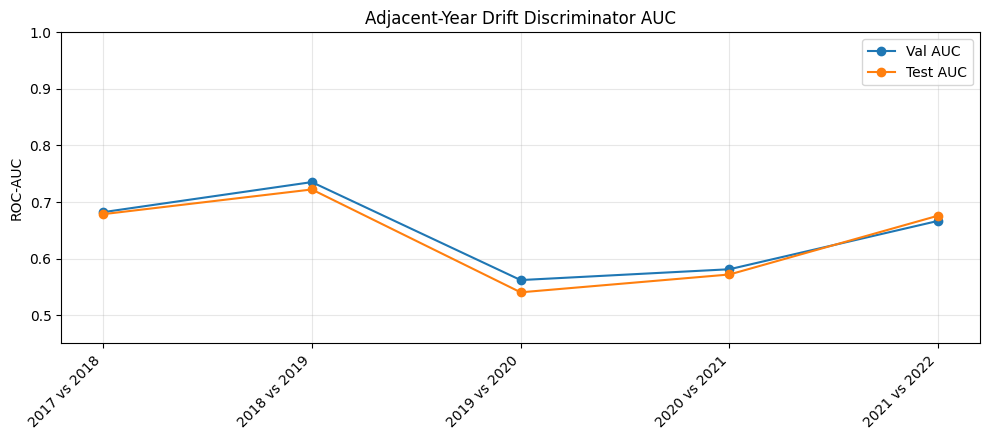

In [6]:
if len(results_df) > 0:
    x = np.arange(len(results_df))

    plt.figure(figsize=(10, 4.5))
    plt.plot(x, results_df["val_auc"], marker="o", label="Val AUC")
    plt.plot(x, results_df["test_auc"], marker="o", label="Test AUC")
    plt.xticks(x, results_df["pair"], rotation=45, ha="right")
    plt.ylim(0.45, 1.0)
    plt.ylabel("ROC-AUC")
    plt.title("Adjacent-Year Drift Discriminator AUC")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

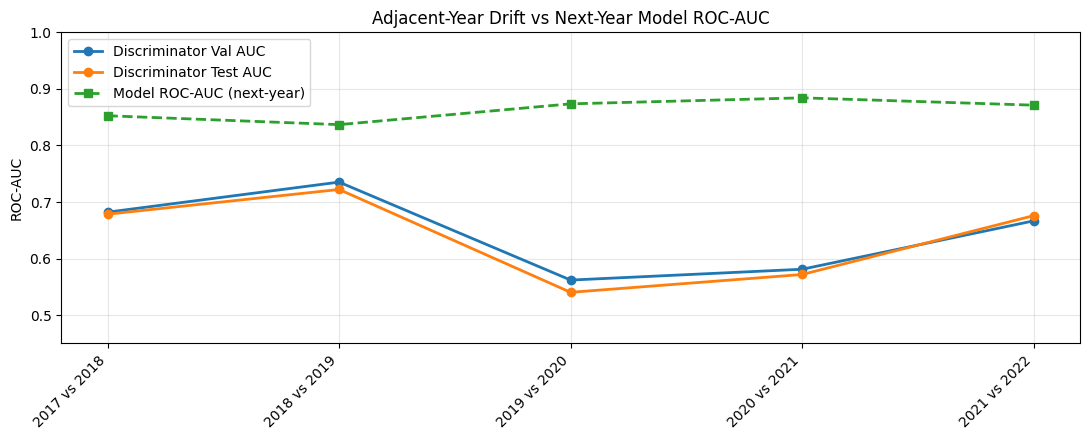

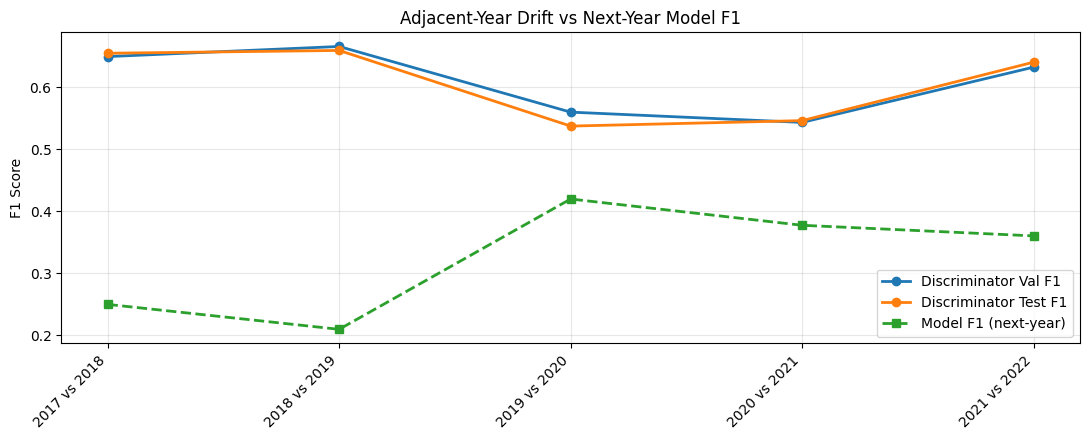

In [11]:
if len(results_df) > 0:
    model_results_path = "sgd_classifier_combined_results_prevyears_monthly_features_incremental_scaler.csv"
    model_metrics_df = pd.read_csv(model_results_path)
    model_metrics_df = (
        model_metrics_df.loc[model_metrics_df["source_id"] == "year_model_next_year", ["year", "roc_auc", "f1_score"]]
        .copy()
        .assign(year=lambda frame: frame["year"].astype(float).astype(int))
        .rename(columns={
            "roc_auc": "model_roc_auc",
            "f1_score": "model_f1",
        })
    )

    # year_model_next_year: model trained on year T (= year_t_minus_1), evaluated on year T+1 (= year_t)
    comparison_df = (
        results_df.merge(
            model_metrics_df,
            left_on="year_t_minus_1",
            right_on="year",
            how="left",
            validate="one_to_one",
        )
        .sort_values("year_t")
        .reset_index(drop=True)
    )

    x = np.arange(len(comparison_df))

    plt.figure(figsize=(11, 4.5))
    plt.plot(x, comparison_df["val_auc"], marker="o", linewidth=2, label="Discriminator Val AUC")
    plt.plot(x, comparison_df["test_auc"], marker="o", linewidth=2, label="Discriminator Test AUC")
    plt.plot(
        x,
        comparison_df["model_roc_auc"],
        marker="s",
        linestyle="--",
        linewidth=2,
        label="Model ROC-AUC (next-year)",
    )
    plt.xticks(x, comparison_df["pair"], rotation=45, ha="right")
    plt.ylim(0.45, 1.0)
    plt.ylabel("ROC-AUC")
    plt.title("Adjacent-Year Drift vs Next-Year Model ROC-AUC")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(11, 4.5))
    plt.plot(x, comparison_df["val_f1"], marker="o", linewidth=2, label="Discriminator Val F1")
    plt.plot(x, comparison_df["test_f1"], marker="o", linewidth=2, label="Discriminator Test F1")
    plt.plot(
        x,
        comparison_df["model_f1"],
        marker="s",
        linestyle="--",
        linewidth=2,
        label="Model F1 (next-year)",
    )
    plt.xticks(x, comparison_df["pair"], rotation=45, ha="right")
    plt.ylabel("F1 Score")
    plt.title("Adjacent-Year Drift vs Next-Year Model F1")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Doscriminator Feature Improtance?

## Method 2: Distribution Drift via MMD and Energy Distance

This section computes **distribution drift** between adjacent years on the **train split** using:
- **MMD (Gaussian/RBF kernel, linear-time estimator)**
- **MMD (Laplacian kernel, linear-time estimator)**
- **Energy Distance (linear-time estimator)**

For runtime stability, we use controlled subsampling and permutation tests for p-values.

In [8]:
# MMD / Energy configuration (balanced runtime)
DRIFT_SAMPLE_SIZE = 30000      # max samples per year for each pairwise statistic
N_PERMUTATIONS = 300           # permutation count for p-value estimation
SIGMA_CALIBRATION_SIZE = 6000 # sample size used to estimate kernel bandwidths
ALPHA = 0.05

rng = np.random.default_rng(RANDOM_STATE)


def _subsample_rows(X, max_n, rng):
    if X is None:
        return None
    if len(X) <= max_n:
        return X
    idx = rng.choice(len(X), size=max_n, replace=False)
    return X[idx]


def estimate_rbf_sigma(X, Y, calib_size=1500, eps=1e-8):
    Xc = _subsample_rows(X, calib_size, rng)
    Yc = _subsample_rows(Y, calib_size, rng)
    Z = np.vstack([Xc, Yc])
    dists = pdist(Z, metric="euclidean")
    med = np.median(dists)
    if not np.isfinite(med) or med <= 0:
        med = 1.0
    return float(max(med, eps))


def estimate_laplacian_bandwidth(X, Y, calib_size=1500, eps=1e-8):
    Xc = _subsample_rows(X, calib_size, rng)
    Yc = _subsample_rows(Y, calib_size, rng)
    Z = np.vstack([Xc, Yc])
    dists = pdist(Z, metric="cityblock")  # L1 distances
    med = np.median(dists)
    if not np.isfinite(med) or med <= 0:
        med = 1.0
    return float(max(med, eps))


def mmd_rbf_linear(X, Y, sigma, rng):
    n = min(len(X), len(Y))
    if n < 4:
        return np.nan

    if n % 2 == 1:
        n -= 1

    x_idx = rng.choice(len(X), size=n, replace=False)
    y_idx = rng.choice(len(Y), size=n, replace=False)
    Xn = X[x_idx]
    Yn = Y[y_idx]

    half = n // 2
    x1, x2 = Xn[:half], Xn[half:]
    y1, y2 = Yn[:half], Yn[half:]

    gamma = 1.0 / (2.0 * sigma * sigma)

    k_xx = np.exp(-gamma * np.sum((x1 - x2) ** 2, axis=1))
    k_yy = np.exp(-gamma * np.sum((y1 - y2) ** 2, axis=1))
    k_xy = np.exp(-gamma * np.sum((x1 - y2) ** 2, axis=1))
    k_yx = np.exp(-gamma * np.sum((x2 - y1) ** 2, axis=1))

    return float(np.mean(k_xx + k_yy - k_xy - k_yx))


def mmd_laplacian_linear(X, Y, bandwidth, rng):
    n = min(len(X), len(Y))
    if n < 4:
        return np.nan

    if n % 2 == 1:
        n -= 1

    x_idx = rng.choice(len(X), size=n, replace=False)
    y_idx = rng.choice(len(Y), size=n, replace=False)
    Xn = X[x_idx]
    Yn = Y[y_idx]

    half = n // 2
    x1, x2 = Xn[:half], Xn[half:]
    y1, y2 = Yn[:half], Yn[half:]

    d_xx = np.sum(np.abs(x1 - x2), axis=1)
    d_yy = np.sum(np.abs(y1 - y2), axis=1)
    d_xy = np.sum(np.abs(x1 - y2), axis=1)
    d_yx = np.sum(np.abs(x2 - y1), axis=1)

    k_xx = np.exp(-d_xx / bandwidth)
    k_yy = np.exp(-d_yy / bandwidth)
    k_xy = np.exp(-d_xy / bandwidth)
    k_yx = np.exp(-d_yx / bandwidth)

    return float(np.mean(k_xx + k_yy - k_xy - k_yx))


def energy_distance_linear(X, Y, rng):
    n = min(len(X), len(Y))
    if n < 4:
        return np.nan

    if n % 2 == 1:
        n -= 1

    x_idx = rng.choice(len(X), size=n, replace=False)
    y_idx = rng.choice(len(Y), size=n, replace=False)
    Xn = X[x_idx]
    Yn = Y[y_idx]

    half = n // 2
    x1, x2 = Xn[:half], Xn[half:]
    y1, y2 = Yn[:half], Yn[half:]

    e_xy = np.mean(np.linalg.norm(x1 - y1, axis=1))
    e_xx = np.mean(np.linalg.norm(x1 - x2, axis=1))
    e_yy = np.mean(np.linalg.norm(y1 - y2, axis=1))

    return float(2.0 * e_xy - e_xx - e_yy)


def permutation_p_value(X, Y, stat_fn, n_perm, rng, **kwargs):
    observed = stat_fn(X, Y, rng=rng, **kwargs)
    if not np.isfinite(observed):
        return np.nan, np.nan

    Z = np.vstack([X, Y])
    n_x = len(X)
    perm_stats = np.empty(n_perm, dtype=float)

    for i in range(n_perm):
        perm_idx = rng.permutation(len(Z))
        Xp = Z[perm_idx[:n_x]]
        Yp = Z[perm_idx[n_x:]]
        perm_stats[i] = stat_fn(Xp, Yp, rng=rng, **kwargs)

    p_val = (1.0 + np.sum(perm_stats >= observed)) / (n_perm + 1.0)
    return float(observed), float(p_val)

In [9]:
print("Starting Gaussian/Laplacian MMD + Energy drift analysis on TRAIN split...")

# Reuse train split prepared in classifier section; fallback if needed
if "ds_train" not in globals():
    ds_train = ds.isel(pixel=train_pixel_indices)

mmd_energy_results = []
skipped_dist_pairs = []

pair_iterator = range(2, n_years)
for pair_idx, idx_curr in enumerate(pair_iterator, start=1):
    idx_prev = idx_curr - 1
    year_prev = int(year_values[idx_prev])
    year_curr = int(year_values[idx_curr])
    pair_name = f"{year_prev} vs {year_curr}"

    print(f"\n[{pair_idx}/{n_pairs}] {pair_name}")
    pair_start = time.time()

    prep_start = time.time()
    X_prev, _ = prepare_features_for_year(ds_train, idx_prev)
    X_curr, _ = prepare_features_for_year(ds_train, idx_curr)
    prep_time = time.time() - prep_start

    if X_prev is None or X_curr is None:
        skipped_dist_pairs.append((pair_name, "missing features after filtering"))
        print("  ✗ SKIP: missing features")
        continue

    if X_prev.shape[1] != X_curr.shape[1]:
        skipped_dist_pairs.append((pair_name, "feature dimension mismatch"))
        print("  ✗ SKIP: feature mismatch")
        continue

    X_prev_s = _subsample_rows(X_prev, DRIFT_SAMPLE_SIZE, rng)
    X_curr_s = _subsample_rows(X_curr, DRIFT_SAMPLE_SIZE, rng)

    print(f"  → Feature prep: {prep_time:.1f}s | n_prev={len(X_prev):,}, n_curr={len(X_curr):,}")
    print(f"  → Subsampled to n_prev={len(X_prev_s):,}, n_curr={len(X_curr_s):,}")

    sigma_rbf = estimate_rbf_sigma(X_prev_s, X_curr_s, calib_size=SIGMA_CALIBRATION_SIZE)
    bandwidth_lap = estimate_laplacian_bandwidth(X_prev_s, X_curr_s, calib_size=SIGMA_CALIBRATION_SIZE)
    print(f"  → RBF sigma (median heuristic): {sigma_rbf:.4f}")
    print(f"  → Laplacian bandwidth (L1 median): {bandwidth_lap:.4f}")

    stat_start = time.time()
    mmd_rbf_stat, mmd_rbf_p = permutation_p_value(
        X_prev_s,
        X_curr_s,
        stat_fn=mmd_rbf_linear,
        n_perm=N_PERMUTATIONS,
        rng=rng,
        sigma=sigma_rbf,
    )

    mmd_lap_stat, mmd_lap_p = permutation_p_value(
        X_prev_s,
        X_curr_s,
        stat_fn=mmd_laplacian_linear,
        n_perm=N_PERMUTATIONS,
        rng=rng,
        bandwidth=bandwidth_lap,
    )

    energy_stat, energy_p = permutation_p_value(
        X_prev_s,
        X_curr_s,
        stat_fn=energy_distance_linear,
        n_perm=N_PERMUTATIONS,
        rng=rng,
    )
    stat_time = time.time() - stat_start

    pair_time = time.time() - pair_start

    mmd_energy_results.append({
        "pair": pair_name,
        "year_t_minus_1": year_prev,
        "year_t": year_curr,
        "n_prev": int(len(X_prev)),
        "n_curr": int(len(X_curr)),
        "n_used": int(min(len(X_prev_s), len(X_curr_s))),
        "sigma_rbf": float(sigma_rbf),
        "bandwidth_lap": float(bandwidth_lap),
        "mmd_rbf_stat": float(mmd_rbf_stat),
        "mmd_rbf_pvalue": float(mmd_rbf_p),
        "mmd_lap_stat": float(mmd_lap_stat),
        "mmd_lap_pvalue": float(mmd_lap_p),
        "energy_stat": float(energy_stat),
        "energy_pvalue": float(energy_p),
        "prep_time_sec": float(prep_time),
        "stat_time_sec": float(stat_time),
        "time_sec": float(pair_time),
    })

    print(f"  ✓ MMD (Gaussian)={mmd_rbf_stat:.6f} (p={mmd_rbf_p:.4f})")
    print(f"  ✓ MMD (Laplacian)={mmd_lap_stat:.6f} (p={mmd_lap_p:.4f})")
    print(f"  ✓ Energy={energy_stat:.6f} (p={energy_p:.4f})")
    print(f"  ✓ Pair time: {pair_time:.1f}s")

mmd_energy_df = pd.DataFrame(mmd_energy_results).sort_values("year_t").reset_index(drop=True)

print(f"\n{'='*70}")
print("MMD / ENERGY ANALYSIS COMPLETE")
print(f"{'='*70}")
if len(mmd_energy_df) > 0:
    print(f"Pairs analyzed: {len(mmd_energy_df)}")
    print(f"Avg pair time: {mmd_energy_df['time_sec'].mean():.1f}s")
    print(f"MMD Gaussian significant (p<{ALPHA}): {(mmd_energy_df['mmd_rbf_pvalue'] < ALPHA).sum()}")
    print(f"MMD Laplacian significant (p<{ALPHA}): {(mmd_energy_df['mmd_lap_pvalue'] < ALPHA).sum()}")
    print(f"Energy significant (p<{ALPHA}): {(mmd_energy_df['energy_pvalue'] < ALPHA).sum()}")
print(f"{'='*70}\n")

if len(mmd_energy_df) == 0:
    print("No valid pairs for MMD/Energy analysis.")
else:
    display(mmd_energy_df)

if skipped_dist_pairs:
    print("\nSkipped pairs:")
    for pair_name, reason in skipped_dist_pairs:
        print(f"  - {pair_name}: {reason}")

Starting Gaussian/Laplacian MMD + Energy drift analysis on TRAIN split...

[1/5] 2017 vs 2018
  → Feature prep: 15.0s | n_prev=5,596,320, n_curr=5,596,320
  → Subsampled to n_prev=30,000, n_curr=30,000
  → RBF sigma (median heuristic): 0.1372
  → Laplacian bandwidth (L1 median): 0.2926
  ✓ MMD (Gaussian)=-0.005783 (p=0.9003)
  ✓ MMD (Laplacian)=0.005528 (p=0.0365)
  ✓ Energy=0.002361 (p=0.0930)
  ✓ Pair time: 24.3s

[2/5] 2018 vs 2019
  → Feature prep: 14.9s | n_prev=5,596,320, n_curr=5,596,320
  → Subsampled to n_prev=30,000, n_curr=30,000
  → RBF sigma (median heuristic): 0.1349
  → Laplacian bandwidth (L1 median): 0.2866
  ✓ MMD (Gaussian)=0.000522 (p=0.4452)
  ✓ MMD (Laplacian)=-0.000522 (p=0.5249)
  ✓ Energy=0.000040 (p=0.5050)
  ✓ Pair time: 24.3s

[3/5] 2019 vs 2020
  → Feature prep: 14.2s | n_prev=5,596,320, n_curr=5,596,320
  → Subsampled to n_prev=30,000, n_curr=30,000
  → RBF sigma (median heuristic): 0.1362
  → Laplacian bandwidth (L1 median): 0.2919
  ✓ MMD (Gaussian)=0.00

,pair,year_t_minus_1,year_t,n_prev,n_curr,n_used,sigma_rbf,bandwidth_lap,mmd_rbf_stat,mmd_rbf_pvalue,mmd_lap_stat,mmd_lap_pvalue,energy_stat,energy_pvalue,prep_time_sec,stat_time_sec,time_sec
0,2017 vs 2018,2017,2018,5596320,5596320,30000,0.137242,0.2926,-0.005783,0.900332,0.005528,0.036545,0.002361,0.093023,14.958849,7.467736,24.316184
1,2018 vs 2019,2018,2019,5596320,5596320,30000,0.134925,0.2866,0.000522,0.445183,-0.000522,0.524917,0.000040,0.504983,14.885709,7.598609,24.251660
2,2019 vs 2020,2019,2020,5596320,5596320,30000,0.136233,0.2919,0.002095,0.335548,-0.002106,0.774086,0.001880,0.149502,14.200633,7.601956,23.522512
3,2020 vs 2021,2020,2021,5596320,5596320,30000,0.138125,0.2921,0.009103,0.019934,-0.000319,0.591362,-0.000592,0.614618,13.937593,7.745895,23.508636
4,2021 vs 2022,2021,2022,5596320,5596320,30000,0.142121,0.3038,-0.001533,0.617940,0.002532,0.259136,-0.000980,0.667774,13.994037,7.568422,23.326433


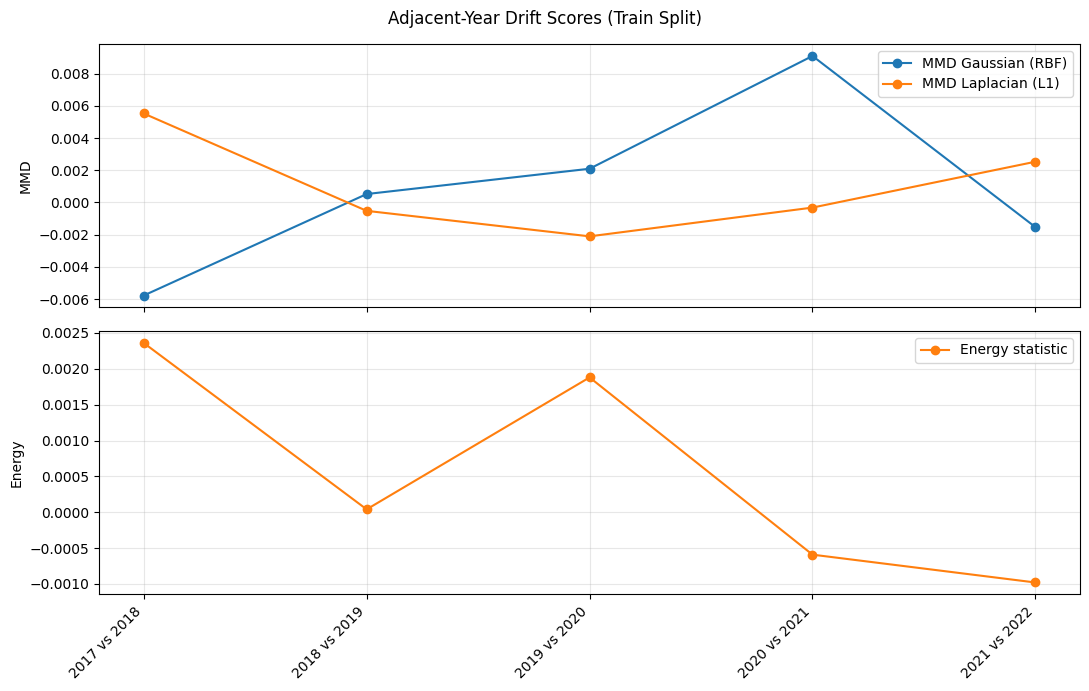

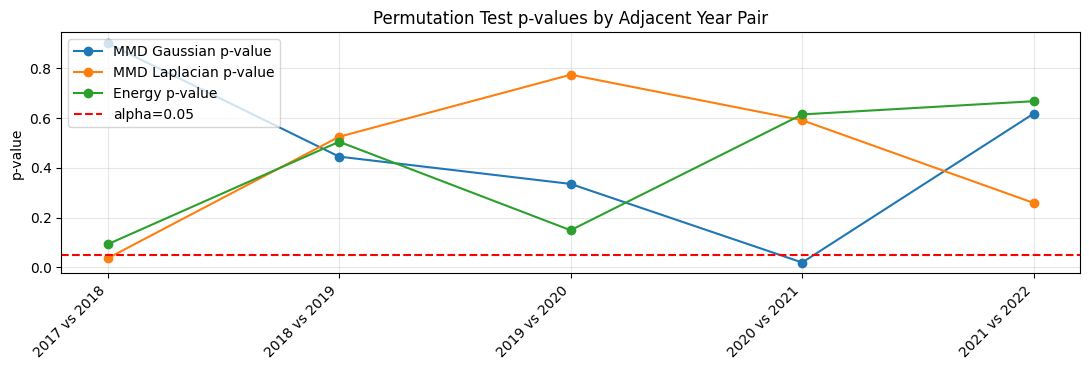

In [10]:
if len(mmd_energy_df) > 0:
    x = np.arange(len(mmd_energy_df))

    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

    axes[0].plot(x, mmd_energy_df["mmd_rbf_stat"], marker="o", label="MMD Gaussian (RBF)")
    axes[0].plot(x, mmd_energy_df["mmd_lap_stat"], marker="o", label="MMD Laplacian (L1)")
    axes[0].set_ylabel("MMD")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(x, mmd_energy_df["energy_stat"], marker="o", color="tab:orange", label="Energy statistic")
    axes[1].set_ylabel("Energy")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(mmd_energy_df["pair"], rotation=45, ha="right")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.suptitle("Adjacent-Year Drift Scores (Train Split)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(11, 3.8))
    plt.plot(x, mmd_energy_df["mmd_rbf_pvalue"], marker="o", label="MMD Gaussian p-value")
    plt.plot(x, mmd_energy_df["mmd_lap_pvalue"], marker="o", label="MMD Laplacian p-value")
    plt.plot(x, mmd_energy_df["energy_pvalue"], marker="o", label="Energy p-value")
    plt.axhline(ALPHA, linestyle="--", color="red", label=f"alpha={ALPHA}")
    plt.xticks(x, mmd_energy_df["pair"], rotation=45, ha="right")
    plt.ylabel("p-value")
    plt.title("Permutation Test p-values by Adjacent Year Pair")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()